# Clustering Project



Goal : Try out all the parameters that can be changed in this KMeans

### Imports

In [148]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples


Dowloading/Loading Dataset

In [149]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Mall_Customers.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "kandij/mall-customers",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

C:\Users\fbase\AppData\Local\Temp\ipykernel_21096\1782252800.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


### Data Overview

In [150]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Data Cleaning and EDA

In [151]:
df = df.rename(columns={"Annual Income (k$)":"annual_income",
                        "Spending Score (1-100)":"spending_score"}
)

In [152]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'annual_income', 'spending_score'], dtype='str')

In [153]:
df.columns = ['customerid','sex','age',"annual_income","spending_score"]

In [154]:
df.columns

Index(['customerid', 'sex', 'age', 'annual_income', 'spending_score'], dtype='str')

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      200 non-null    int64
 1   sex             200 non-null    str  
 2   age             200 non-null    int64
 3   annual_income   200 non-null    int64
 4   spending_score  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


<Axes: >

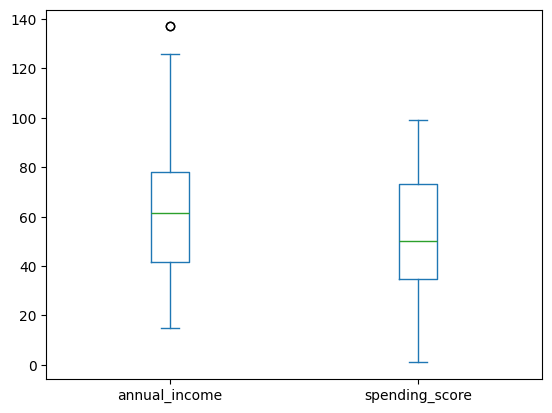

In [156]:
df[['annual_income','spending_score']].plot(kind="box")

<Axes: ylabel='Frequency'>

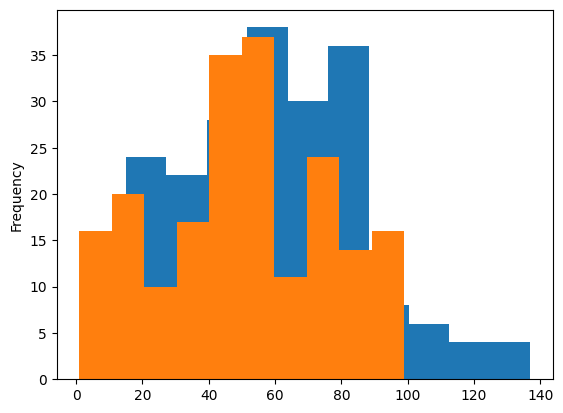

In [157]:
df['annual_income'].plot(kind="hist")
df['spending_score'].plot(kind="hist")

## Data PreProcessing and Model training

In [158]:
scaler = StandardScaler()

In [159]:
X_scaled = scaler.fit_transform(df.iloc[:,3:])

In [160]:
model1 = KMeans()

In [161]:
model1.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [162]:
labels = model1.labels_

In [163]:
labels

array([3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 7, 0, 7, 7,
       3, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 2, 7, 7, 2, 2, 7, 7, 7, 7,
       7, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6, 2, 4, 2, 6, 1, 4, 1, 4,
       2, 4, 1, 6, 1, 4, 1, 4, 1, 6, 2, 6, 1, 6, 2, 4, 1, 6, 1, 6, 1, 4,
       1, 6, 1, 4, 1, 4, 2, 6, 1, 6, 1, 4, 1, 6, 1, 4, 1, 4, 1, 6, 1, 6,
       1, 4, 1, 6, 1, 5, 1, 5, 1, 6, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5,
       1, 5], dtype=int32)

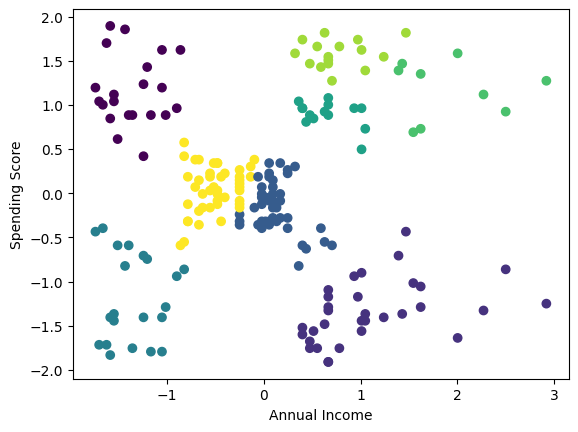

In [164]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

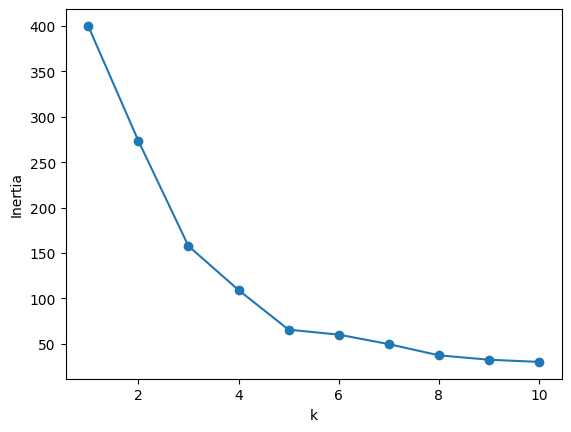

In [165]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

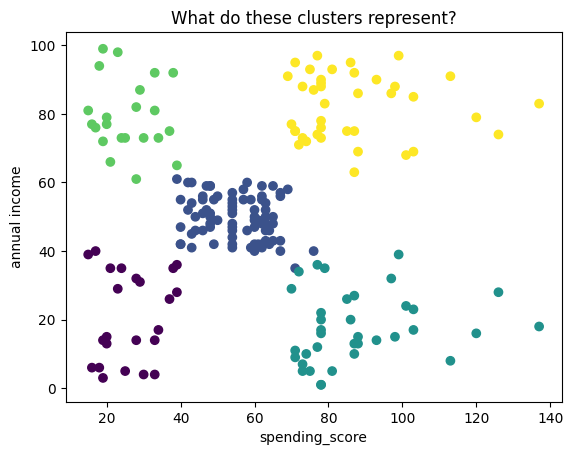

In [166]:
model2 = KMeans(n_clusters=5)
model2.fit(X_scaled)

plt.scatter(df.annual_income,df.spending_score,c=model2.labels_,cmap='viridis')
plt.xlabel("spending_score")
plt.ylabel("annual income")
plt.title("What do these clusters represent?")
plt.show()

In [167]:
df['Cluster'] = model2.labels_
df.groupby('Cluster')[['age', 'annual_income', 'spending_score']].mean()

,age,annual_income,spending_score
Cluster,,,
0,45.217391,26.304348,20.913043
1,42.937500,55.087500,49.712500
2,40.666667,87.750000,17.583333
3,25.272727,25.727273,79.363636
4,32.692308,86.538462,82.128205


Adding `age` to the dataset

In [168]:
X_scaled2 = scaler.fit_transform(df[['age','annual_income','spending_score']])

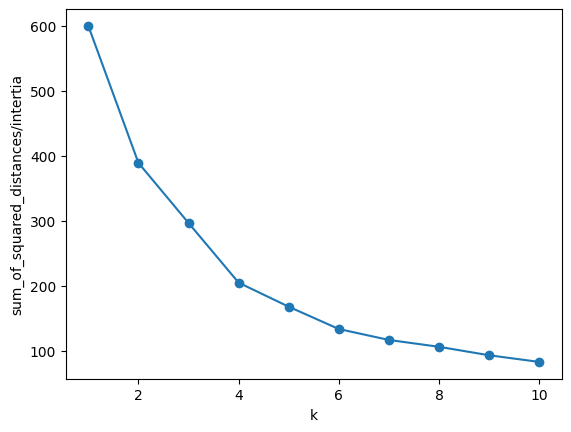

In [169]:
sum_of_squared_distances = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit(X_scaled2)
    sum_of_squared_distances.append(km.inertia_)

plt.plot(np.arange(1,11),sum_of_squared_distances,marker='o')
plt.xlabel('k')
plt.ylabel('sum_of_squared_distances/intertia')
plt.show()

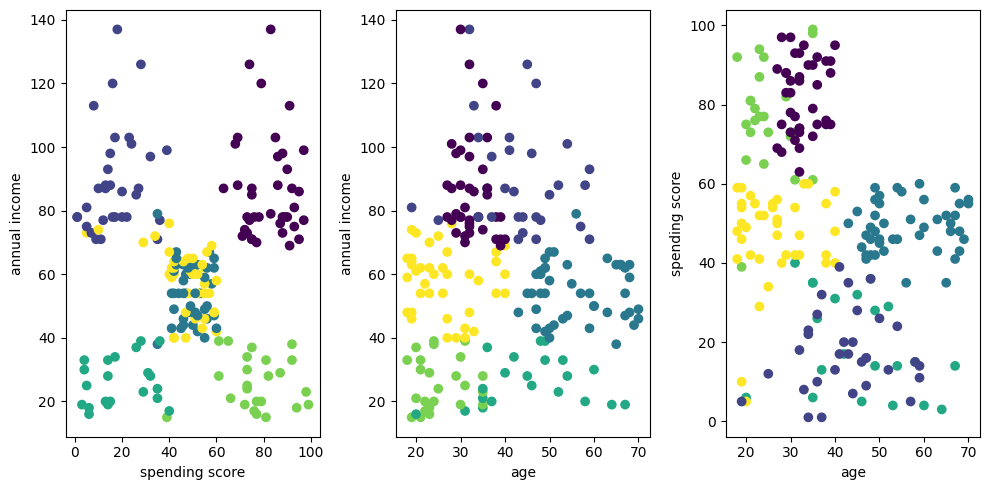

In [170]:
model3 = KMeans(n_clusters=6)
model3.fit(X_scaled2)

fig,ax = plt.subplots(ncols=3, nrows=1, figsize=(10,5))
ax = ax.flatten()

ax[0].scatter(df.spending_score,df.annual_income,c=model3.labels_,cmap='viridis')
ax[0].set_xlabel('spending score')
ax[0].set_ylabel('annual income')

ax[1].scatter(df.age,df.annual_income,c=model3.labels_,cmap='viridis')
ax[1].set_xlabel('age')
ax[1].set_ylabel('annual income')

ax[2].scatter(df.age,df.spending_score,c=model3.labels_,cmap='viridis')
ax[2].set_xlabel('age')
ax[2].set_ylabel('spending score')

plt.tight_layout()
plt.show()

## Dataset 2 - Practice

### Data Downloading

In [171]:
# Set the path to the file you'd like to load
file_path = "student_study_habits.csv"

# Load the latest version
df2 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prekshad2166/student-study-habits",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

C:\Users\fbase\AppData\Local\Temp\ipykernel_21096\1997413468.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df2 = kagglehub.load_dataset(


### Data Overview


In [172]:
df2.head()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.421400,0.881883,0.883478,0.555556,62.240021,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.552393,0.220286,0.683469,1.000000,65.268855,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.698283,0.612594,0.520094,0.222222,66.609921,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.405419,0.369871,0.831127,0.333333,58.967484,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [173]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   study_hours_per_week            500 non-null    float64
 1   sleep_hours_per_day             500 non-null    float64
 2   attendance_percentage           500 non-null    float64
 3   assignments_completed           500 non-null    float64
 4   final_grade                     500 non-null    float64
 5   participation_level_Low         500 non-null    float64
 6   participation_level_Medium      500 non-null    float64
 7   internet_access_Yes             500 non-null    float64
 8   parental_education_High School  500 non-null    float64
 9   parental_education_Master's     500 non-null    float64
 10  parental_education_PhD          500 non-null    float64
 11  extracurricular_Yes             500 non-null    float64
 12  part_time_job_Yes               500 non-null   

### EDA

- study_hours_per_week : average study hours = No of hours spent study / 168 (Total no of hours in a week)
- sleep_hours_per_day : average daily sleep duration = Sum of hours slept perday / No of hours in a week
- attendence_percentage : class percentage rate = (no fo classes attended / total no of classes) * 100
- assignments_completed = no of assignments done / total no of assignments
- participation_level_OHE_columns : participation level in class

Rest of the columns can are easy to understand

In [174]:
columns = df2.iloc[:,:5].columns
df2[columns].describe()[1:].style.background_gradient(cmap='magma')

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade
mean,0.445603,0.506387,0.684110,0.533556,63.753071
std,0.162325,0.194923,0.214918,0.276109,7.114183
min,0.000000,0.000000,0.000000,0.000000,40.200403
25%,0.327727,0.380942,0.530386,0.333333,58.813933
50%,0.446577,0.505706,0.697383,0.555556,63.822553
75%,0.550575,0.630248,0.844194,0.777778,68.588277
max,1.000000,1.000000,1.000000,1.000000,92.007807


In [175]:

fig = px.box(df2, y = "study_hours_per_week",
             points = "all", notched = True,
             title = "Distribution",
             width=700,
             height=700)

fig.update_traces(marker = dict(size = 4, symbol = "circle-open"))
fig.update_traces(fillcolor = "#000000")
fig.update_layout(template = "plotly_dark")

fig.show()

In [176]:
df2.final_grade.describe()

count    500.000000
mean      63.753071
std        7.114183
min       40.200403
25%       58.813933
50%       63.822553
75%       68.588277
max       92.007807
Name: final_grade, dtype: float64

In [177]:
df2.columns

Index(['study_hours_per_week', 'sleep_hours_per_day', 'attendance_percentage',
       'assignments_completed', 'final_grade', 'participation_level_Low',
       'participation_level_Medium', 'internet_access_Yes',
       'parental_education_High School', 'parental_education_Master's',
       'parental_education_PhD', 'extracurricular_Yes', 'part_time_job_Yes'],
      dtype='str')

<Axes: xlabel='study_hours_per_week', ylabel='sleep_hours_per_day'>

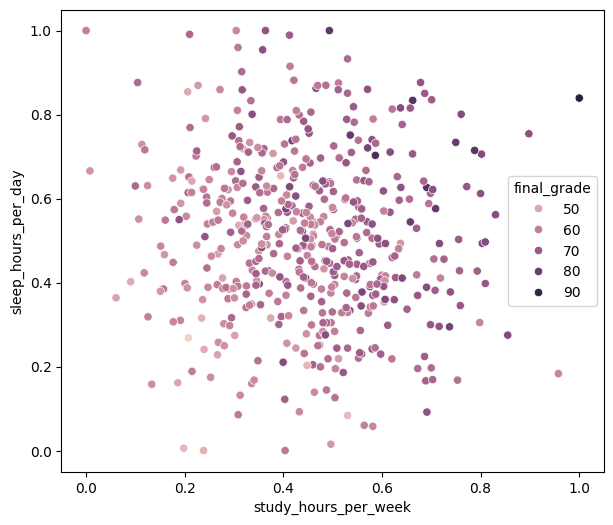

In [178]:
plt.figure(figsize=(7,6))
sns.scatterplot(df2,x='study_hours_per_week',y='sleep_hours_per_day',hue='final_grade')

In [179]:
df2.corr().style.background_gradient(cmap='magma')

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
study_hours_per_week,1.000000,-0.075378,-0.064476,0.012121,0.517297,-0.042347,0.053687,0.022966,0.010111,0.004026,0.062669,-0.012191,0.024995
sleep_hours_per_day,-0.075378,1.000000,0.078977,-0.040785,0.237757,0.002322,0.006176,0.019395,-0.127791,0.020758,0.038618,-0.031848,0.018154
attendance_percentage,-0.064476,0.078977,1.000000,-0.049445,0.196920,-0.111465,0.040078,-0.015378,0.005628,0.066900,-0.013727,-0.013577,-0.021553
assignments_completed,0.012121,-0.040785,-0.049445,1.000000,0.389298,0.054175,-0.004972,0.005433,0.013700,-0.056510,-0.003839,-0.006331,0.071540
final_grade,0.517297,0.237757,0.196920,0.389298,1.000000,-0.337384,-0.013224,0.107834,-0.181262,0.079005,0.203578,0.000821,-0.160734
participation_level_Low,-0.042347,0.002322,-0.111465,0.054175,-0.337384,1.000000,-0.487273,0.049513,0.089210,-0.071573,-0.072036,0.036724,-0.020529
participation_level_Medium,0.053687,0.006176,0.040078,-0.004972,-0.013224,-0.487273,1.000000,0.020721,-0.061948,0.131868,0.031697,0.003657,0.004545
internet_access_Yes,0.022966,0.019395,-0.015378,0.005433,0.107834,0.049513,0.020721,1.000000,-0.061479,-0.022244,0.006912,-0.026443,-0.022273
parental_education_High School,0.010111,-0.127791,0.005628,0.013700,-0.181262,0.089210,-0.061948,-0.061479,1.000000,-0.328829,-0.175992,0.020334,-0.032479
parental_education_Master's,0.004026,0.020758,0.066900,-0.056510,0.079005,-0.071573,0.131868,-0.022244,-0.328829,1.000000,-0.158067,-0.043680,0.081784


In [180]:
model4 = KMeans(n_clusters=4)
model4.fit(df2.drop(columns='final_grade'))

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [181]:
df2['cluster_labels']= model4.labels_

In [182]:
df2.groupby('cluster_labels')[['study_hours_per_week','sleep_hours_per_day','attendance_percentage','assignments_completed','final_grade']].mean()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade
cluster_labels,,,,,
0,0.444606,0.463800,0.689087,0.537598,62.785967
1,0.431954,0.507286,0.636543,0.563256,58.987220
2,0.456773,0.534859,0.707284,0.531481,65.722878
3,0.446362,0.510325,0.692613,0.516049,65.645945


hmm non-interpretable

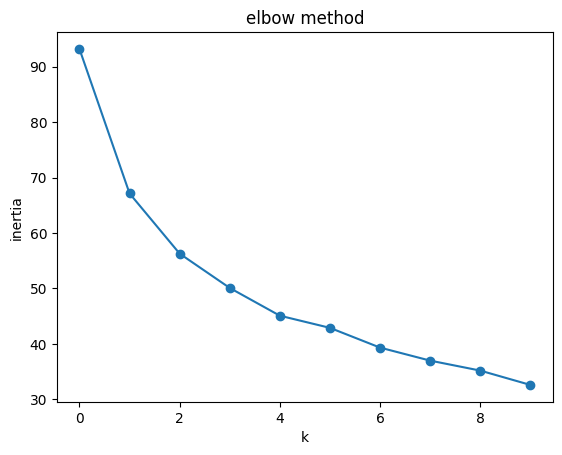

In [183]:
inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k)
    km.fit(df2.iloc[:,:4])
    inertia.append(km.inertia_)

plt.plot(np.arange(len(inertia)),inertia,marker='o')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('elbow method')
plt.show()

In [184]:
model5 = KMeans(n_clusters=2)
model5.fit(df2.iloc[:,:4])
df2['cluster_labels']= model5.labels_

In [185]:
df2.groupby('cluster_labels')[['study_hours_per_week','sleep_hours_per_day','attendance_percentage','assignments_completed','final_grade']].mean()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade
cluster_labels,,,,,
0,0.446573,0.515539,0.717659,0.314310,61.789985
1,0.444576,0.496708,0.648628,0.765432,65.829257


## Dataset 3 - Practice

In [186]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "carrie1/ecommerce-data",
  file_path,
  pandas_kwargs={"encoding": "latin-1"}
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


C:\Users\fbase\AppData\Local\Temp\ipykernel_21096\2325809109.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


### Connecting SQL

In [187]:
# Make a .db file
conn = sqlite3.connect("datasets/Project_3_UCI_online_retail.db")

# Connect the .db file to df ( it has a csv file )
# data is the name of the table in the .db file ( Iss table me csv file se data aya h)
df.to_sql("data", conn, if_exists="replace", index=False)

541909

### Data Cleaning

In [188]:
dfc = df.copy()

In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [190]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

##### Handling NaN

In [191]:
# Percentage of NaNs
(df.isna().sum() / df.shape[0] ) * 100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

`Description`

In [192]:
df.dropna(subset=['Description'],inplace=True)

`CustomerID`

In [193]:
# This is unique identification number I don't think that I will be using its values
df.CustomerID.unique

<bound method Series.unique of 0         17850.0
1         17850.0
2         17850.0
3         17850.0
4         17850.0
           ...   
541904    12680.0
541905    12680.0
541906    12680.0
541907    12680.0
541908    12680.0
Name: CustomerID, Length: 540455, dtype: float64>

##### Checking For and Dropping Irrelevant Columns and Rows

In [194]:
df.drop(columns=['CustomerID'],inplace=True)

##### Handling duplicates

In [195]:
dfc.duplicated().sum()
# About ~1-2% dropable

np.int64(5268)

Can we have dupllicated values?

Individual Columns
- InvoiceNo : Yes, If there are multiple items, Each Row is a item entry
- StockCode : Yes, its just location
- Description : Yes, Every item can be sold more than once ofc
- Quantity : Yes
- UnitPrice : Yes
- Country : Yes
- CustomerID : Yes
  
Rows?  
- same location , same item , same quantity , same unit price , same country : Yes
- same invoice, same customer id too? : No  
If the same customer is buying the same thing the it should be one entry not two, if the customer is different then the invoice and custome id should be different too.

Unless this was done **manually**, but we can't figure this out so we won't consider this possibility
  
So Do we drop it or do we merge these entries? because if it really is an error then that means they bought twice of the usual quantity
  
- Chances of invoice being split in half in two seperate entries by accident is **low**, doesn't sound realistic  
- Chances of a entry being duplicated sounds more **realistic**

In [196]:
df.drop(df[df.duplicated()].index,axis=0,inplace=True)

`UnitPrice`

In [197]:
df.drop(df.query('UnitPrice <= 0').index,axis=0,inplace=True)

### Data Exploration

In [198]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,United Kingdom


Just trying out sql queries

In [199]:
pd.read_sql_query("SELECT * FROM data LIMIT 2",conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [200]:
df.Description.value_counts()[:10]

Description
WHITE HANGING HEART T-LIGHT HOLDER    2353
REGENCY CAKESTAND 3 TIER              2187
JUMBO BAG RED RETROSPOT               2153
PARTY BUNTING                         1719
LUNCH BAG RED RETROSPOT               1625
ASSORTED COLOUR BIRD ORNAMENT         1488
SET OF 3 CAKE TINS PANTRY DESIGN      1465
PACK OF 72 RETROSPOT CAKE CASES       1367
LUNCH BAG  BLACK SKULL.               1323
NATURAL SLATE HEART CHALKBOARD        1272
Name: count, dtype: int64

In [201]:
df.Quantity.agg(['min','max'])
# What?

min   -80995
max    80995
Name: Quantity, dtype: int64

I want to see the range of values in Quantity 

<Axes: >

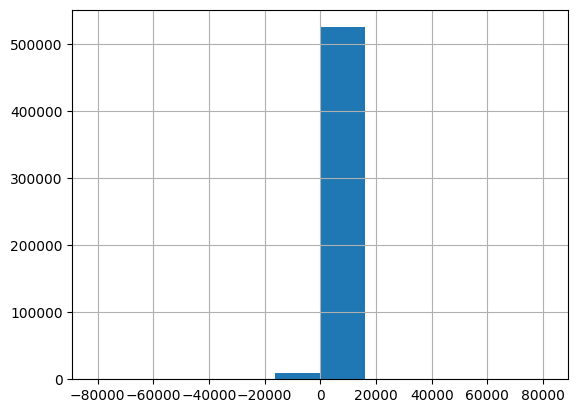

In [202]:
df.Quantity.hist()

<Axes: >

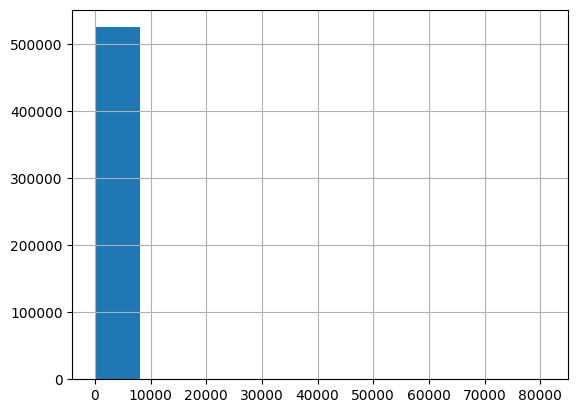

In [203]:
df.query('Quantity > 0').Quantity.hist() 

(array([5.24876e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00]),
 array([1.00000e+00, 8.10040e+03, 1.61998e+04, 2.42992e+04, 3.23986e+04,
        4.04980e+04, 4.85974e+04, 5.66968e+04, 6.47962e+04, 7.28956e+04,
        8.09950e+04]),
 <BarContainer object of 10 artists>)

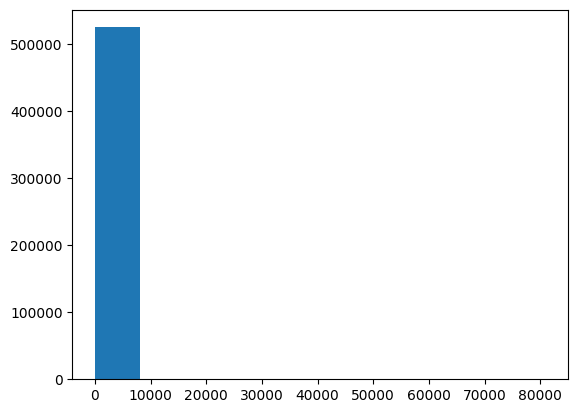

In [204]:
plt.hist(df.loc[df.Quantity>0,'Quantity'])
# Strange why does it show only one bar

<Axes: >

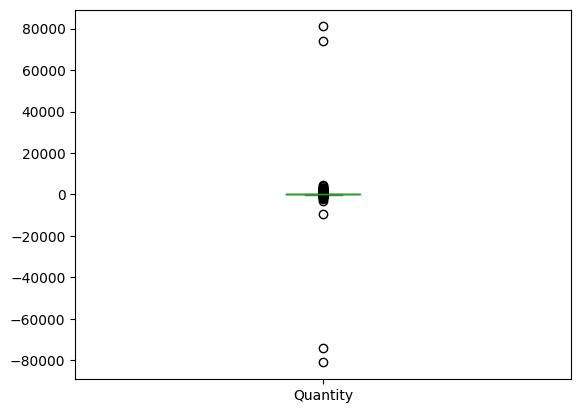

In [205]:
df.Quantity.plot(kind='box')

Have been unable to because of Outliers and histogram behaving strangely

In [206]:
df.Quantity.unique() #Can't believe that this array is giving me a beter idea of distribution than the plots
# Whats the negative values for does it imply that bought = +ve and sold = -ve ?

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     72,    200,    600,
          480,     -6,     14,     -2,     11,     33,     13,     -4,
           -5,     -7,     -3,     70,    252,     60,    216,    384,
           27,     15,     22,     19,     17,     21,     34,     47,
          108,     52,  -9360,     75,    270,     42,    240,     90,
          320,   1824,    204,     69,    -36,   -192,   -144,    160,
         2880,   1400,     39,    -48,    -50,     56,     26,   1440,
           31,     82,     78,     97,     98,     35,     -8,    720,
          -20,    156,    324,     38,     37,     49,     95,     -9,
          -11,     29,     41,    -10,    -72,    402,    378,    150,
      

<Axes: >

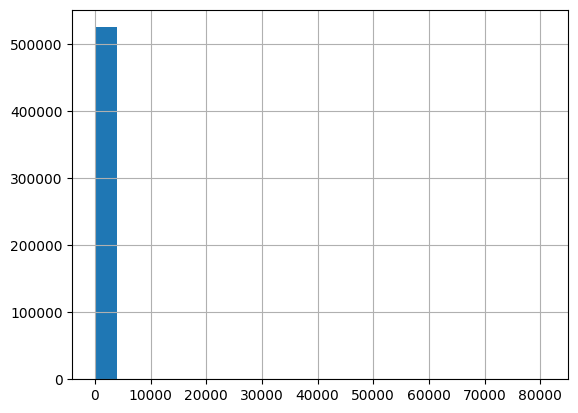

In [207]:
# Maybe its because at default bins=1 that is why we were seeing only 1 bar
df.query('Quantity > 0').Quantity.hist(bins=20) 
# Yea idk why this is not working

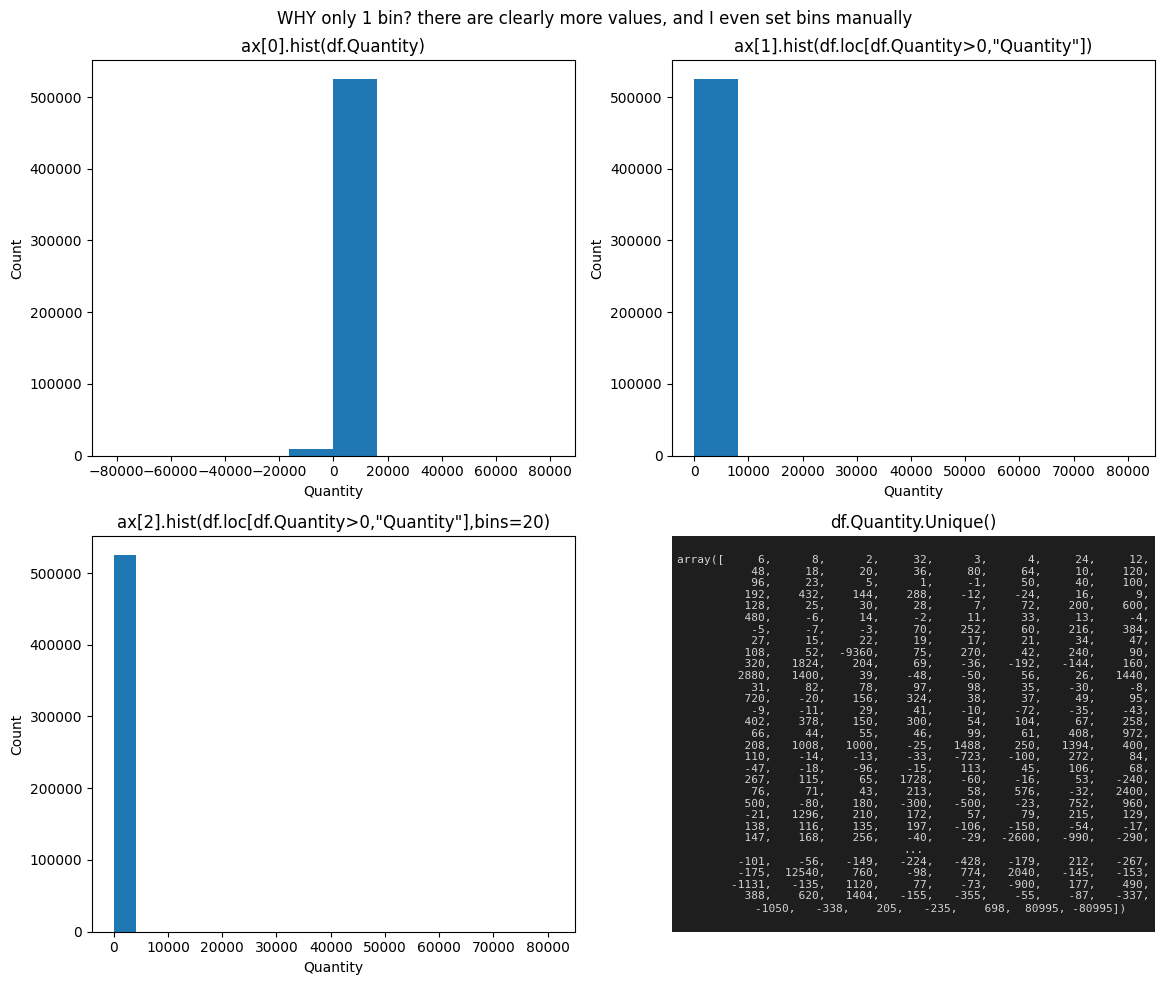

In [208]:
# Just a compilation the 4 plots for linkedin
fig, ax = plt.subplots(2,2,figsize=(12,10))
ax = ax.flatten()

ax[0].hist(df.Quantity)
ax[0].set_ylabel('Count')
ax[0].set_xlabel('Quantity')
ax[0].set_title('ax[0].hist(df.Quantity)')

ax[1].hist(df.loc[df.Quantity>0,'Quantity'])
ax[1].set_ylabel('Count')
ax[1].set_xlabel('Quantity')
ax[1].set_title('ax[1].hist(df.loc[df.Quantity>0,"Quantity"])')

ax[2].hist(df.loc[df.Quantity>0,'Quantity'],bins=20)
ax[2].set_ylabel('Count')
ax[2].set_xlabel('Quantity')
ax[2].set_title('ax[2].hist(df.loc[df.Quantity>0,"Quantity"],bins=20)')

output = """array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     72,    200,    600,
          480,     -6,     14,     -2,     11,     33,     13,     -4,
           -5,     -7,     -3,     70,    252,     60,    216,    384,
           27,     15,     22,     19,     17,     21,     34,     47,
          108,     52,  -9360,     75,    270,     42,    240,     90,
          320,   1824,    204,     69,    -36,   -192,   -144,    160,
         2880,   1400,     39,    -48,    -50,     56,     26,   1440,
           31,     82,     78,     97,     98,     35,    -30,     -8,
          720,    -20,    156,    324,     38,     37,     49,     95,
           -9,    -11,     29,     41,    -10,    -72,    -35,    -43,
          402,    378,    150,    300,     54,    104,     67,    258,
           66,     44,     55,     46,     99,     61,    408,    972,
          208,   1008,   1000,    -25,   1488,    250,   1394,    400,
          110,    -14,    -13,    -33,   -723,   -100,    272,     84,
          -47,    -18,    -96,    -15,    113,     45,    106,     68,
          267,    115,     65,   1728,    -60,    -16,     53,   -240,
           76,     71,     43,    213,     58,    576,    -32,   2400,
          500,    -80,    180,   -300,   -500,    -23,    752,    960,
          -21,   1296,    210,    172,     57,     79,    215,    129,
          138,    116,    135,    197,   -106,   -150,    -54,    -17,
          147,    168,    256,    -40,    -29,  -2600,   -990,   -290,
...
         -101,    -56,   -149,   -224,   -428,   -179,    212,   -267,
         -175,  12540,    760,    -98,    774,   2040,   -145,   -153,
        -1131,   -135,   1120,     77,    -73,   -900,    177,    490,
          388,    620,   1404,   -155,   -355,    -55,    -87,   -337,
        -1050,   -338,    205,   -235,    698,  80995, -80995])"""

ax[3].text(
    0.5,0.5,
    output,
    transform=ax[3].transAxes,
    fontsize=8,
    color="#d4d4d4",      # VS Code text color
    family="monospace",
    ha='center',
    va='center'
)
ax[3].set_xticks([])
ax[3].set_yticks([])

for spine in ax[3].spines.values():
    spine.set_visible(False)

ax[3].patch.set_facecolor("#1e1e1e")

ax[3].set_title('df.Quantity.Unique()')

plt.suptitle('WHY only 1 bin? there are clearly more values, and I even set bins manually')
plt.tight_layout()
plt.show()

In [209]:
# df.city.unique()
pd.read_sql_query("SELECT DISTINCT Country From data", conn)

,Country
0,United Kingdom
1,France
2,Australia
3,Netherlands
4,Germany
5,Norway
6,EIRE
7,Switzerland
8,Spain
9,Poland


In [210]:
#df.Country.value_counts()
pd.read_sql_query("SELECT Country, COUNT(*) as count FROM data GROUP BY Country ORDER BY count DESC", conn)

,Country,count
0,United Kingdom,495478
1,Germany,9495
2,France,8557
3,EIRE,8196
4,Spain,2533
5,Netherlands,2371
6,Belgium,2069
7,Switzerland,2002
8,Portugal,1519
9,Australia,1259


In [211]:
# Trying out sql query
pd.read_sql_query("SELECT Country, COUNT(*) as count FROM data", conn)

,Country,count
0,United Kingdom,541909


In [212]:
# Trying out sql query
pd.read_sql_query("SELECT Country, COUNT(*) as count FROM data GROUP BY Country", conn)

,Country,count
0,Australia,1259
1,Austria,401
2,Bahrain,19
3,Belgium,2069
4,Brazil,32
5,Canada,151
6,Channel Islands,758
7,Cyprus,622
8,Czech Republic,30
9,Denmark,389


In [213]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,United Kingdom


In [214]:
# df.Description.unique()
pd.read_sql_query("SELECT DISTINCT Description from data",conn)

,Description
0,WHITE HANGING HEART T-LIGHT HOLDER
1,WHITE METAL LANTERN
2,CREAM CUPID HEARTS COAT HANGER
3,KNITTED UNION FLAG HOT WATER BOTTLE
4,RED WOOLLY HOTTIE WHITE HEART.
...,...
4219,????damages????
4220,mixed up
4221,lost
4222,CREAM HANGING HEART T-LIGHT HOLDER


In [215]:
# df.Description.value_counts()
pd.read_sql_query("SELECT Description,COUNT(*) as count FROM data GROUP BY Description ORDER BY count DESC", conn)

,Description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2369
1,REGENCY CAKESTAND 3 TIER,2200
2,JUMBO BAG RED RETROSPOT,2159
3,PARTY BUNTING,1727
4,LUNCH BAG RED RETROSPOT,1638
...,...,...
4219,20713,1
4220,16 PC CUTLERY SET PANTRY DESIGN,1
4221,*Boombox Ipod Classic,1
4222,TOADSTOOL BEDSIDE LIGHT,1


<Axes: title={'center': 'UnitPrice Distribution'}, xlabel='UnitPrice', ylabel='Count'>

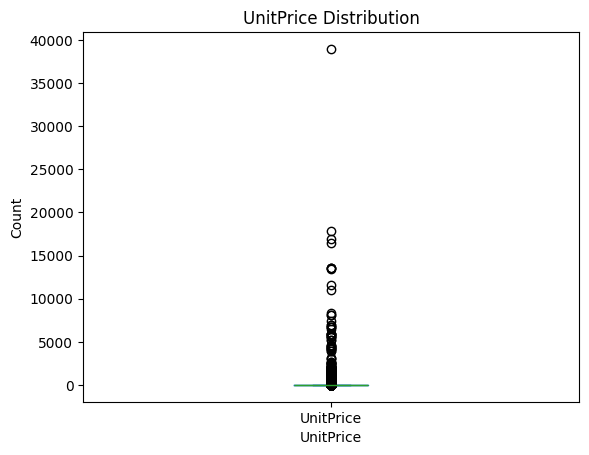

In [216]:
# Trying to see where most values lie
df.UnitPrice.plot(kind='box',xlabel='UnitPrice',ylabel='Count',title='UnitPrice Distribution')


In [217]:
df.UnitPrice.describe()

count    534129.000000
mean          4.695864
std          95.079189
min           0.001000
25%           1.250000
50%           2.100000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [218]:
df.query('UnitPrice < 0')['UnitPrice']

Series([], Name: UnitPrice, dtype: float64)

<Axes: xlabel='count', ylabel='Country'>

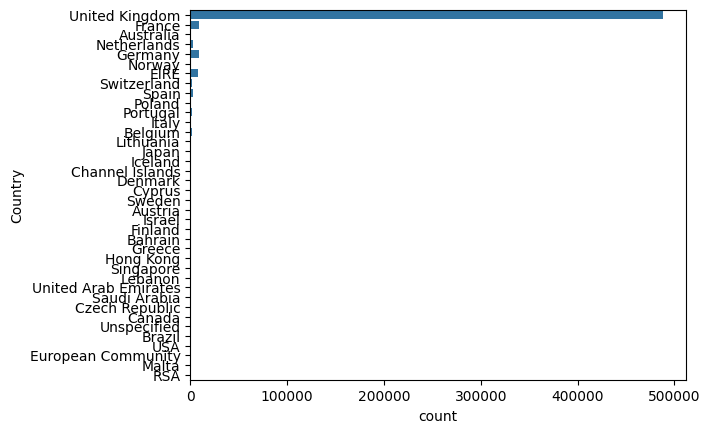

In [219]:
country_dist = sns.countplot(df.Country)
country_dist

In [220]:
df.Country.value_counts()

Country
United Kingdom          487806
Germany                   9478
France                    8540
EIRE                      8180
Spain                     2527
Netherlands               2367
Belgium                   2069
Switzerland               1993
Portugal                  1510
Australia                 1255
Norway                    1085
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         57


## DataPreprocessing

In [221]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,United Kingdom


I need to make numerical features out of Remaining features  
Ideas I have
- OHE
- target encoding
- value_counts / freq encoding

In [222]:
for i in ['StockCode','Description','Country']:
    string = i+'_enc'
    freq = df[i].value_counts()
    df[string] = df[i].map(freq)

## Model Training


Trying out freq encoding 

In [223]:
numerical_features = ['Quantity','UnitPrice','StockCode_enc','Description_enc','Country_enc']

In [224]:
scaler = MinMaxScaler()
X_Scaled = scaler.fit_transform(df[numerical_features])
print(X_Scaled)

[[5.00037039e-01 6.54092909e-05 1.00000000e+00 1.00000000e+00
  1.00000000e+00]
 [5.00037039e-01 8.69643338e-05 1.51700087e-01 1.36904762e-01
  1.00000000e+00]
 [5.00049386e-01 7.05414439e-05 1.26852659e-01 1.23724490e-01
  1.00000000e+00]
 ...
 [5.00024693e-01 1.06466515e-04 1.34263296e-01 1.27551020e-01
  1.74868183e-02]
 [5.00024693e-01 1.06466515e-04 6.97471665e-02 6.80272109e-02
  1.74868183e-02]
 [5.00018520e-01 1.26995128e-04 4.20226678e-01 4.09863946e-01
  1.74868183e-02]]


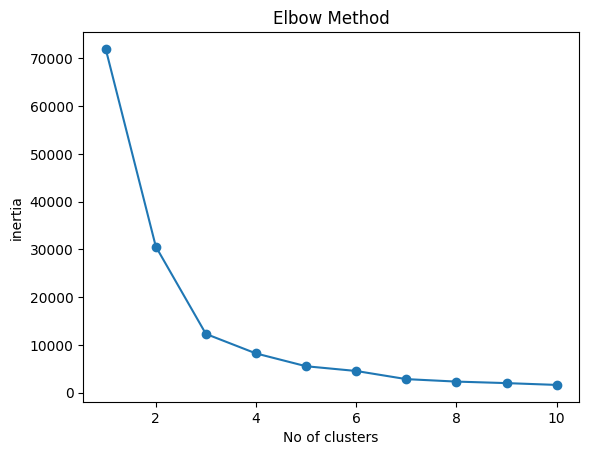

In [225]:
inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k)
    km.fit(X_Scaled)
    inertia.append(km.inertia_)

plt.plot(np.arange(1,11),inertia,marker='o')
plt.xlabel('No of clusters')
plt.ylabel('inertia')
plt.title('Elbow Method')
plt.show()

In [226]:
model = KMeans(n_clusters=5)
model.fit(X_Scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [227]:
df['cluster_labels'] = model.labels_


In [228]:
with pd.option_context('display.max_columns',None):
    display(df.groupby('cluster_labels')[numerical_features].mean())

,Quantity,UnitPrice,StockCode_enc,Description_enc,Country_enc
cluster_labels,,,,,
0,8.031493,4.445342,161.300235,159.769667,487806.000000
1,19.725688,5.424644,433.603796,424.426884,5575.790111
2,11.043531,3.105223,1008.701117,968.893228,487806.000000
3,13.345178,5.273081,1919.118040,1929.684473,464735.454597
4,9.300601,5.617987,483.796571,478.343183,487806.000000


In [229]:
(df.groupby('cluster_labels')[numerical_features].mean()).corr()

,Quantity,UnitPrice,StockCode_enc,Description_enc,Country_enc
Quantity,1.000000,0.331455,0.145006,0.145426,-0.917752
UnitPrice,0.331455,1.000000,-0.029552,-0.008115,-0.369065
StockCode_enc,0.145006,-0.029552,1.000000,0.999655,0.255122
Description_enc,0.145426,-0.008115,0.999655,1.000000,0.253091
Country_enc,-0.917752,-0.369065,0.255122,0.253091,1.000000


## Model Evaluation

In [230]:
# Evaluating why UnitPrice can Have such values
df.query('UnitPrice > 1.24 and UnitPrice <=4.13' ).UnitPrice.sum()

np.float64(663709.68)

In [231]:
# This many values are between 0 - 4.13 exluding 1 outlier
75/100 * df.shape[0] 

400596.75

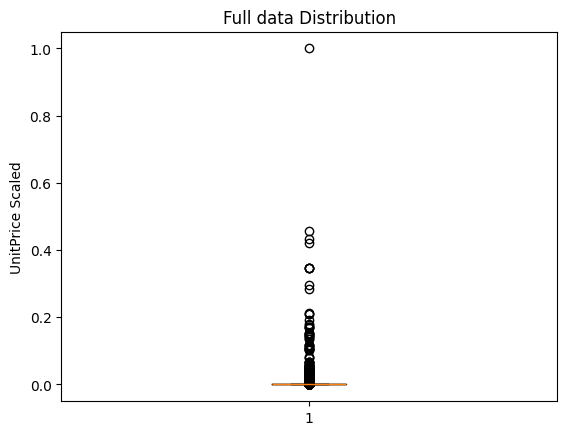

In [232]:
# Huh the outliers didn't change huh
plt.boxplot(X_Scaled[:,1])
plt.ylabel("UnitPrice Scaled")
plt.title('Full data Distribution')
plt.show()

In [233]:
p75 = np.percentile(X_Scaled[:,1],75)
p75

np.float64(0.00010595330012710547)

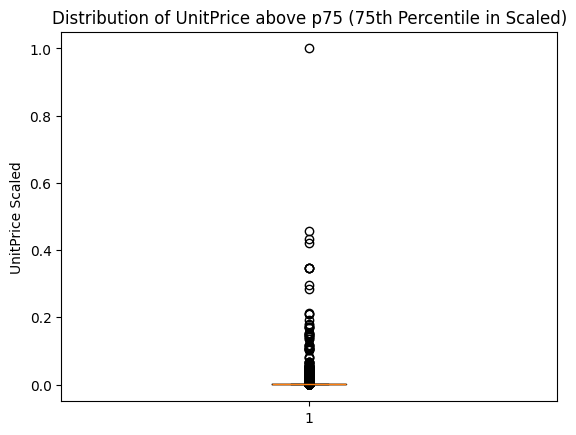

In [234]:
# I want to see like how many values are there , still the same boxplot huh
var = X_Scaled[:,1]
plt.boxplot(var[var>p75])
plt.ylabel("UnitPrice Scaled")
plt.title("Distribution of UnitPrice above p75 (75th Percentile in Scaled)")
plt.show()

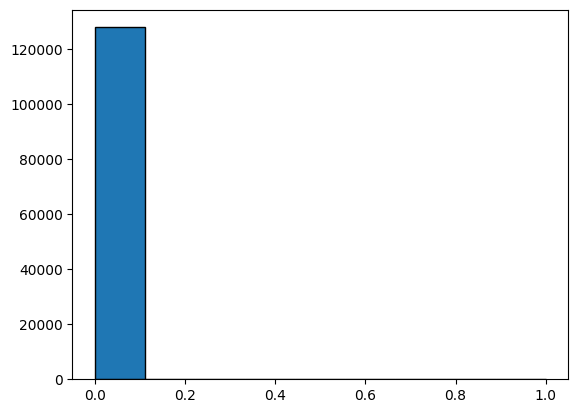

In [235]:
plt.hist(var[var>p75],bins=9,edgecolor='black')
plt.show()

In [236]:
var[var>4.13]

array([], dtype=float64)

In [237]:
counts, edges = np.histogram(df['UnitPrice'], bins=9)
print(counts)
print(edges)

[534093     26      2      6      1      0      0      0      1]
[1.00000000e-03 4.33000089e+03 8.66000078e+03 1.29900007e+04
 1.73200006e+04 2.16500004e+04 2.59800003e+04 3.03100002e+04
 3.46400001e+04 3.89700000e+04]


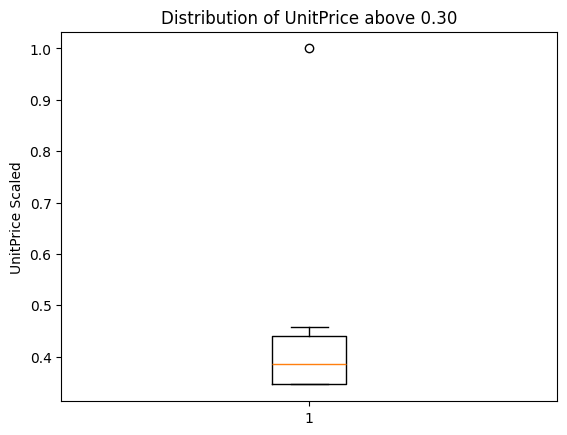

In [238]:
# Lets try this
var = X_Scaled[:,1]
plt.boxplot(var[var>0.30])
plt.ylabel("UnitPrice Scaled")
plt.title("Distribution of UnitPrice above 0.30")
plt.show()
# Finally something different

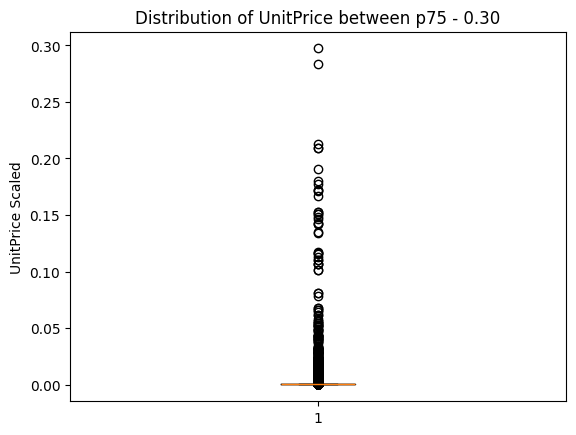

In [239]:
var = X_Scaled[:,1]
plt.boxplot(var[(var>p75) & (var<0.30)])
plt.ylabel("UnitPrice Scaled")
plt.title("Distribution of UnitPrice between p75 - 0.30")
plt.show()

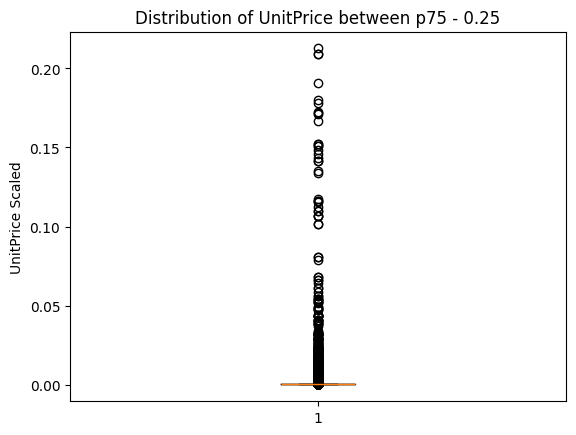

In [240]:
var = X_Scaled[:,1]
plt.boxplot(var[(var>p75) & (var<0.25)])
plt.ylabel("UnitPrice Scaled")
plt.title("Distribution of UnitPrice between p75 - 0.25")
plt.show()
# Okay all values are very close to 0.22 , no need to zoom in any further

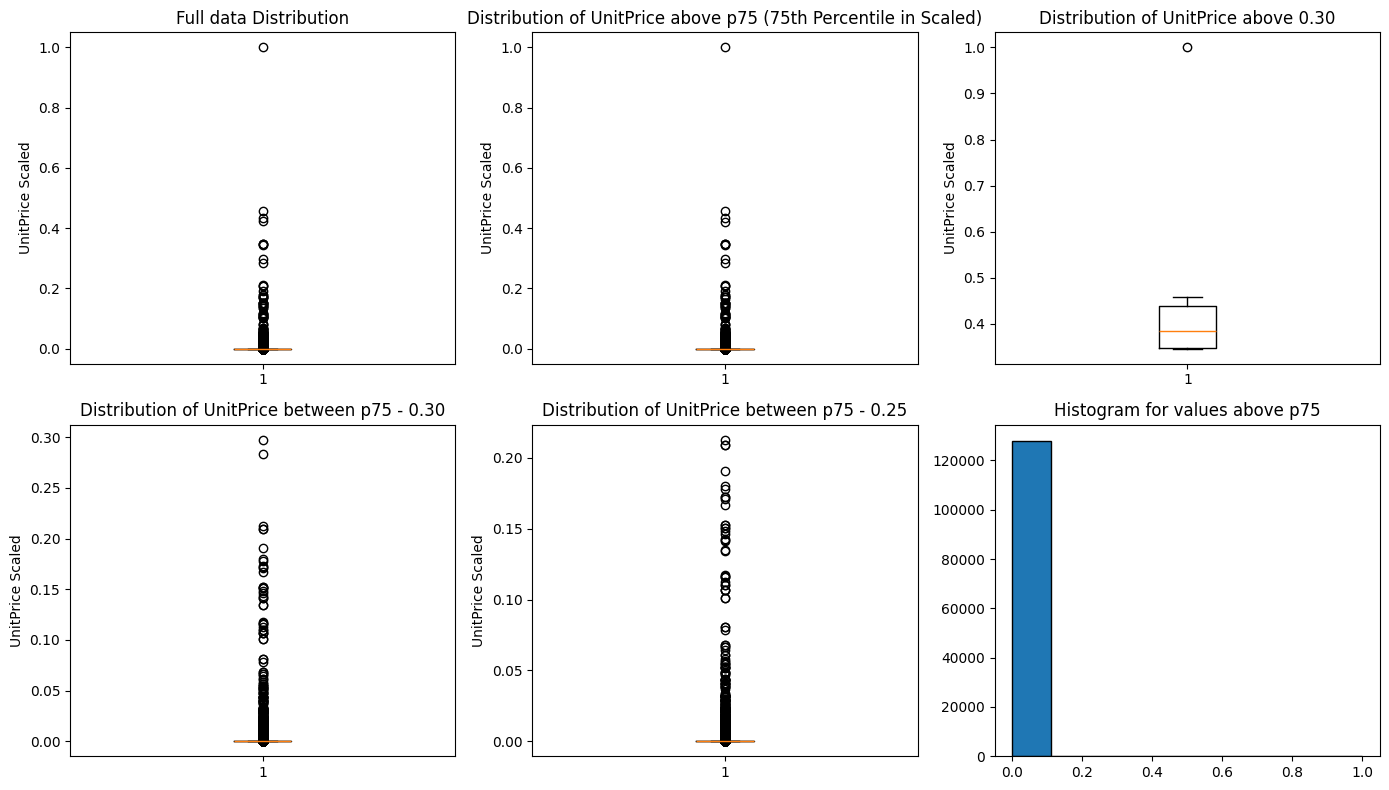

In [241]:
# All plots in a single image
fig , ax = plt.subplots(2,3,figsize=(14,8))
ax = ax.flatten()

var = X_Scaled[:,1]

ax[0].boxplot(var)
ax[0].set_ylabel("UnitPrice Scaled")
ax[0].set_title('Full data Distribution')

ax[1].boxplot(var[var>p75])
ax[1].set_ylabel("UnitPrice Scaled")
ax[1].set_title("Distribution of UnitPrice above p75 (75th Percentile in Scaled)")


ax[2].boxplot(var[var>0.30])
ax[2].set_ylabel("UnitPrice Scaled")
ax[2].set_title("Distribution of UnitPrice above 0.30")



ax[3].boxplot(var[(var>p75) & (var<0.30)])
ax[3].set_ylabel("UnitPrice Scaled")
ax[3].set_title("Distribution of UnitPrice between p75 - 0.30")


ax[4].boxplot(var[(var>p75) & (var<0.25)])
ax[4].set_ylabel("UnitPrice Scaled")
ax[4].set_title("Distribution of UnitPrice between p75 - 0.25")


ax[5].hist(var[var>p75],bins=9,edgecolor='black')
ax[5].set_title('Histogram for values above p75')

plt.tight_layout()
plt.show()

In [242]:
df.groupby('cluster_labels')[numerical_features].mean()
"""
Lets define the no of times a item appears in the Description as Demand
All deals done in UK
cluster 0 : Low Demand , mid UnitPrice , Lowest Quantity compares to the rest
cluster 3 : Highest Demand , Low Unit Price , mid Quantity
cluster 4 : Low-mid but not the lowest demand , high UnitPrice , mid-low lowest Quantity 

Deals from other countries
cluster 1 : low demand , high price, high quantity
cluster 2 : high demand , high price, high quantity

But these two sets of clusters shouldn't be compared to each other because the no of recorded deals of UK are much higher
"""

"\nLets define the no of times a item appears in the Description as Demand\nAll deals done in UK\ncluster 0 : Low Demand , mid UnitPrice , Lowest Quantity compares to the rest\ncluster 3 : Highest Demand , Low Unit Price , mid Quantity\ncluster 4 : Low-mid but not the lowest demand , high UnitPrice , mid-low lowest Quantity \n\nDeals from other countries\ncluster 1 : low demand , high price, high quantity\ncluster 2 : high demand , high price, high quantity\n\nBut these two sets of clusters shouldn't be compared to each other because the no of recorded deals of UK are much higher\n"

In [243]:
df.groupby('cluster_labels')[numerical_features].mean()

,Quantity,UnitPrice,StockCode_enc,Description_enc,Country_enc
cluster_labels,,,,,
0,8.031493,4.445342,161.300235,159.769667,487806.000000
1,19.725688,5.424644,433.603796,424.426884,5575.790111
2,11.043531,3.105223,1008.701117,968.893228,487806.000000
3,13.345178,5.273081,1919.118040,1929.684473,464735.454597
4,9.300601,5.617987,483.796571,478.343183,487806.000000


In [244]:
zscore_frame1 = df[numerical_features]

In [245]:
scaler2 = StandardScaler()
zscore = scaler2.fit_transform(zscore_frame1)
zscore_frame2 = pd.DataFrame(zscore)
zscore_frame2.columns = numerical_features
zscore_frame2.index = df.index

In [246]:
zscore_frame2 = zscore_frame2[abs(zscore_frame2['Quantity']) < 3]
zscore_frame2

,Quantity,UnitPrice,StockCode_enc,Description_enc,Country_enc
0,-0.018096,-0.022569,4.708499,4.954090,0.308149
1,-0.018096,-0.013735,-0.203969,-0.253024,0.308149
2,-0.008856,-0.020466,-0.347859,-0.332542,0.308149
3,-0.018096,-0.013735,0.101483,0.124043,0.308149
4,-0.018096,-0.013735,0.035849,0.057350,0.308149
...,...,...,...,...,...
541904,0.009624,-0.040449,-0.711371,-0.701914,-3.223152
541905,-0.018096,-0.027302,-0.282225,-0.265850,-3.223152
541906,-0.027335,-0.005741,-0.304944,-0.309456,-3.223152
541907,-0.027335,-0.005741,-0.678554,-0.668568,-3.223152


In [247]:
['Quantity','UnitPrice','Description_enc','Country_enc']

['Quantity', 'UnitPrice', 'Description_enc', 'Country_enc']

In [248]:

print(zscore_frame2.index)

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       541899, 541900, 541901, 541902, 541903, 541904, 541905, 541906, 541907,
       541908],
      dtype='int64', length=533871)


In [249]:
# the values that are in zscore_frame2.index but not in df.index
missing = zscore_frame2.index.difference(df.index)
print(missing)

Index([], dtype='int64')


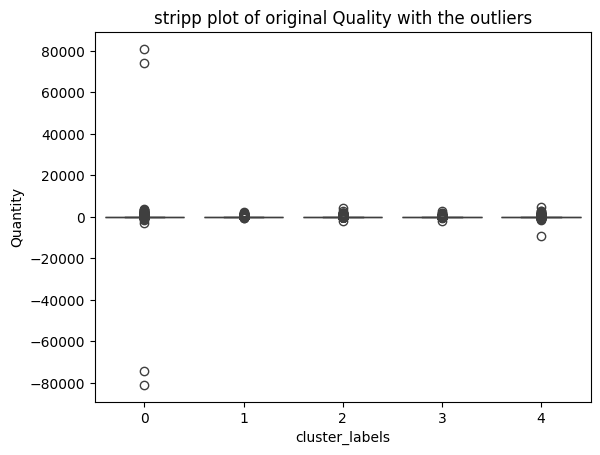

In [250]:
sns.boxplot(data=df[['Quantity','cluster_labels']],x='cluster_labels',y='Quantity')
plt.title('stripp plot of original Quality with the outliers')
plt.show()

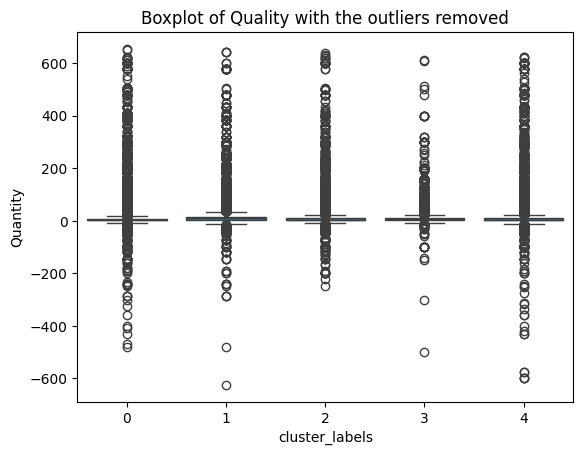

In [251]:
sns.boxplot(data=df.loc[zscore_frame2.index,['Quantity','cluster_labels']],x='cluster_labels',y='Quantity')
plt.title('Boxplot of Quality with the outliers removed')
plt.show()

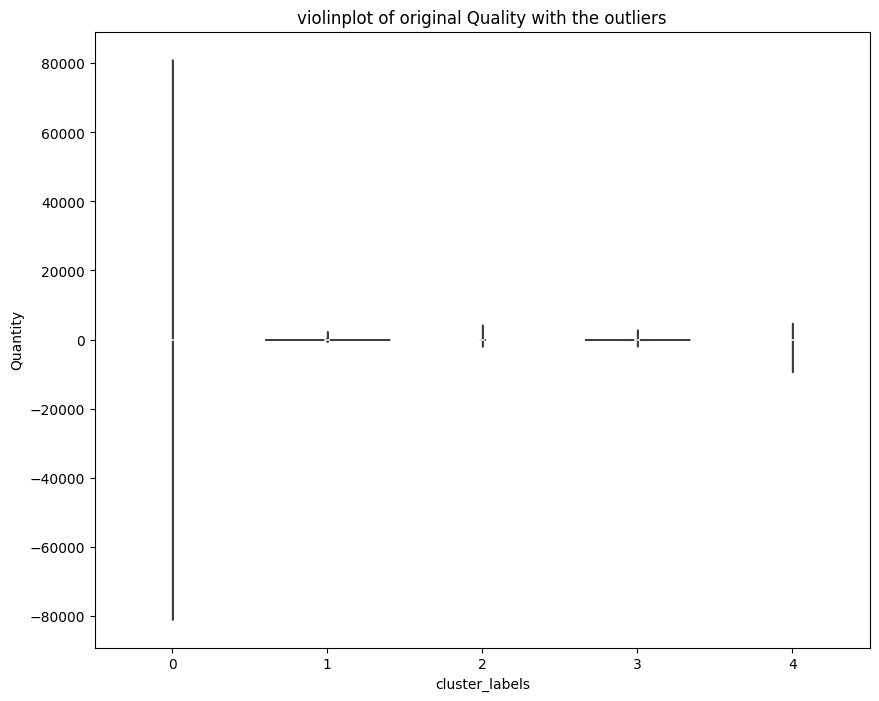

In [252]:
plt.figure(figsize=(10,8))
sns.violinplot(data=df[numerical_features + ['cluster_labels']],x='cluster_labels',y='Quantity')
plt.title('violinplot of original Quality with the outliers')
plt.show()

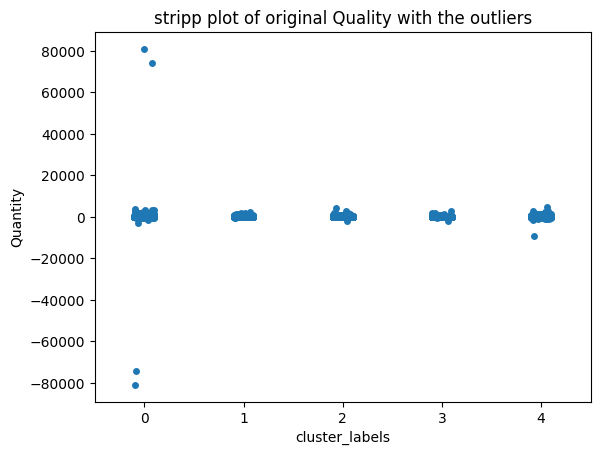

In [253]:
sns.stripplot(data=df[numerical_features + ['cluster_labels']],x='cluster_labels',y='Quantity')
plt.title('stripp plot of original Quality with the outliers')
plt.show()

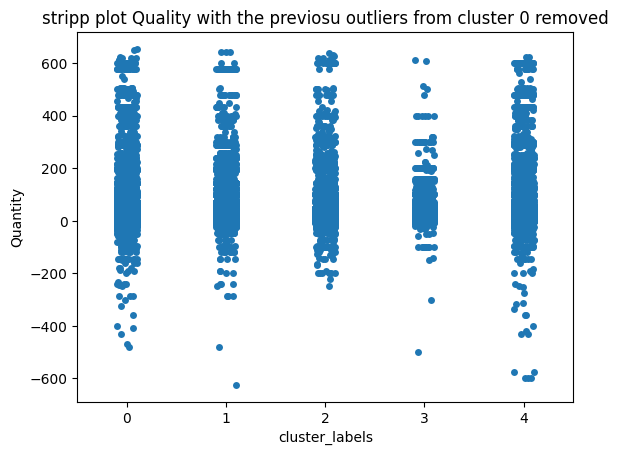

In [254]:
sns.stripplot(data=df.loc[zscore_frame2.index,['Quantity','cluster_labels']],x='cluster_labels',y='Quantity')
plt.title('stripp plot Quality with the previosu outliers from cluster 0 removed')
plt.show()

In [255]:
#sns.swarmplot(data=df.loc[zscore_frame2.index,['Quantity','cluster_labels']],x='cluster_labels',y='Quantity')
#Ptani kitna time tak run hoga

In [256]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Country', 'StockCode_enc', 'Description_enc',
       'Country_enc', 'cluster_labels'],
      dtype='str')

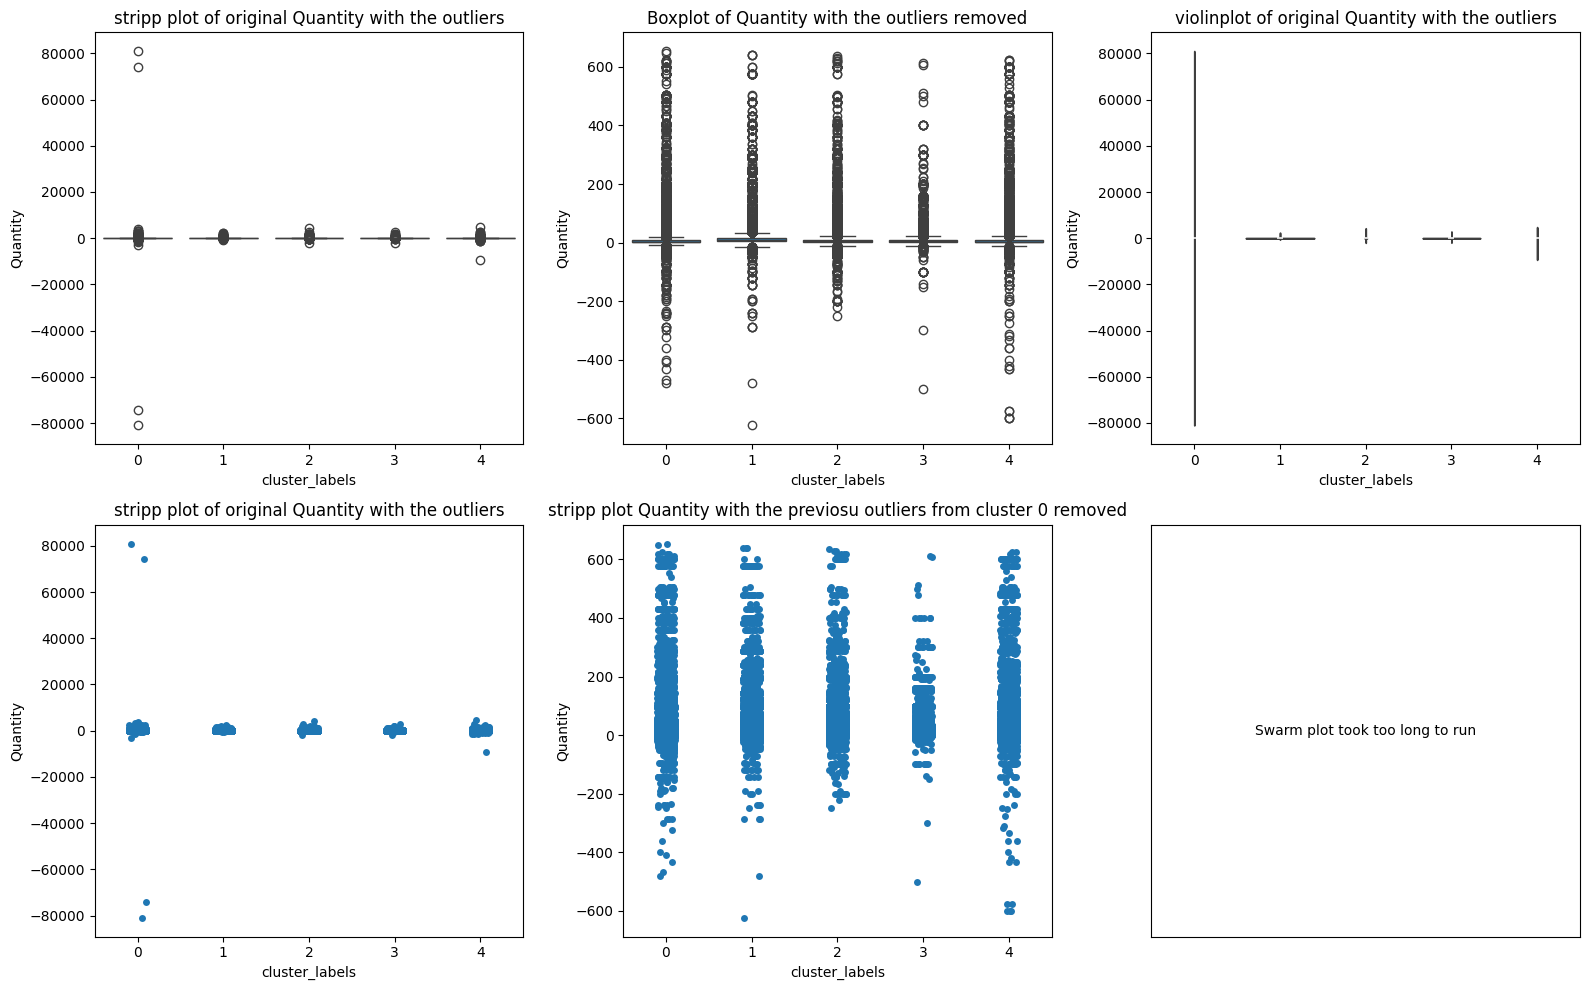

In [267]:
fig , ax = plt.subplots(2,3,figsize=(16,10))

ax = ax.flatten()

sns.boxplot(data=df[['Quantity','cluster_labels']],x='cluster_labels',y='Quantity',ax=ax[0])
ax[0].set_title('stripp plot of original Quantity with the outliers')

sns.boxplot(data=df.loc[zscore_frame2.index,['Quantity','cluster_labels']],x='cluster_labels',y='Quantity',ax=ax[1])
ax[1].set_title('Boxplot of Quantity with the outliers removed')

sns.violinplot(data=df[numerical_features + ['cluster_labels']],x='cluster_labels',y='Quantity',ax=ax[2])
ax[2].set_title('violinplot of original Quantity with the outliers')

sns.stripplot(data=df[numerical_features + ['cluster_labels']],x='cluster_labels',y='Quantity',ax=ax[3])
ax[3].set_title('stripp plot of original Quantity with the outliers')

sns.stripplot(data=df.loc[zscore_frame2.index,['Quantity','cluster_labels']],x='cluster_labels',y='Quantity',ax=ax[4])
ax[4].set_title('stripp plot Quantity with the previosu outliers from cluster 0 removed')

ax[5].set_xticks([])
ax[5].set_yticks([])
ax[5].text(0.5,0.5,"Swarm plot took too long to run",ha='center',va='center',
           transform=ax[5].transAxes)

plt.tight_layout()
plt.show()

In [ ]:
print(silhouette_score(X_scaled, labels))
print(davies_bouldin_score(X_scaled, labels))

0.4574781601062871
0.713028661650938


TypeError: matplotlib.axes._axes.Axes.bar() got multiple values for keyword argument 'x'

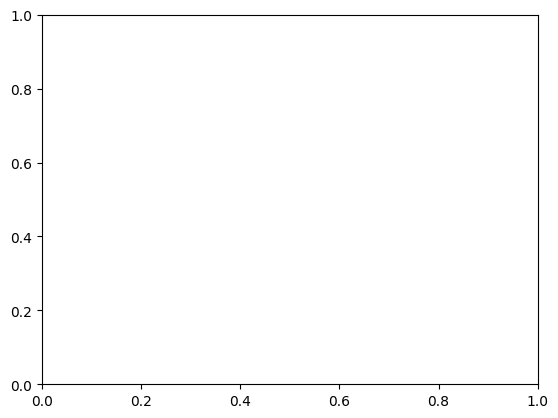

In [ ]:
td = df[numerical_features + ['cluster_labels']]
td['silhouette_score'] = silhouette_score(X_scaled, labels)
plt.barh(data=td,y='silhouette_score',x='cluster_labels',width=0.1)
plt.xlabel('cluster label')
plt.ylabel('silhoutte sample scores')
plt.show()

In [ ]:
X_Scaled.shape

(534129, 5)

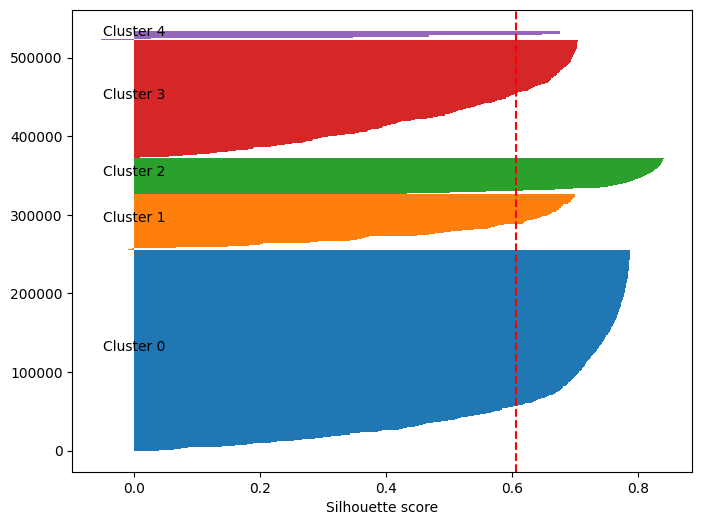

In [ ]:
"""
Don't re run this pls this took 65 mins to run
labels = df['cluster_labels']
# Silhoute sample gets the silhoute sample of each point?
scores = silhouette_samples(X_Scaled, labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 0

for i in range(5):  # 5 clusters
    cluster_scores = sorted(scores[labels == i])
    size = len(cluster_scores)
    y_upper = y_lower + size
    ax.barh(range(y_lower, y_upper), cluster_scores, height=1)
    ax.text(-0.05, y_lower + size / 2, f'Cluster {i}')
    y_lower = y_upper + 5  # small gap between clusters

ax.axvline(x=scores.mean(), color='red', linestyle='--')  # average line
plt.xlabel('Silhouette score')
plt.show()
"""

In [ ]:
#barh(labels,values)

(200,)